# AI-Powered Personal Spending & Financial Behavior Coach
## Notebook 04 — Segmentation & Persona Development (Dataset-Appropriate)

### Objective
Create interpretable customer segments (“personas”) that can be used as structured inputs
to an LLM-powered financial coaching experience.

### Important Note About Dataset Structure
This dataset contains one transaction per customer (transaction_count = 1 for all customers).
As a result, behavioral features requiring multiple transactions (e.g., spending volatility,
frequency, category diversity over time) are not measurable here.

Therefore, personas are defined using:
- Transaction amount tiers (spend intensity)
- Category and merchant context
- Demographics (age, gender)

## 0) Imports and Setup

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1) Load Cleaned Transactions

We use the cleaned dataset from Notebook 01.
We will build segmentation features that are valid for a single-transaction-per-customer dataset.

In [86]:
df = pd.read_csv("cleaned_transactions.csv")

# Ensure date types are parsed (if needed)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")

df.head()

,customer_id,name,surname,gender,birthdate,transaction_amount,date,merchant_name,category,merchant_name_clean,year,month,day,weekday,age,age_group
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic,smith russell,2023,4,3,Monday,23,18-25
1,26381,Michelle,Phelps,Unknown,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",Travel,peck spence and young,2023,7,17,Monday,40,36-45
2,305449,Jacob,Williams,M,1981-10-25,115.97,2023-09-20,Steele Inc,Clothing,steele inc,2023,9,20,Wednesday,44,36-45
3,988259,Nathan,Snyder,M,1977-10-26,11.31,2023-01-11,"Wilson, Wilson and Russell",Cosmetic,wilson wilson and russell,2023,1,11,Wednesday,48,46-55
4,764762,Crystal,Knapp,F,1951-11-02,62.21,2023-06-13,Palmer-Hinton,Electronics,palmer hinton,2023,6,13,Tuesday,74,65+


## 2) Confirm Dataset Structure

We verify that each customer has one transaction.
This confirms why multi-transaction behavior features are not applicable.

In [89]:
txn_counts = df["customer_id"].value_counts()
txn_counts.describe()

count    50000.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: count, dtype: float64

## 3) Build Segmentation Features

Since we cannot compute longitudinal behavior, we build segmentation features based on:
- transaction_amount (spend intensity)
- category context
- merchant context
- age and gender

We create a customer-level table that represents a snapshot segmentation.

In [92]:
# One row per customer (already true in this dataset, but we keep the pattern explicit)
seg_df = df.groupby("customer_id").agg(
    transaction_amount=("transaction_amount", "first"),
    category=("category", "first"),
    merchant=("merchant_name_clean" if "merchant_name_clean" in df.columns else "merchant_name", "first"),
    age=("age", "first") if "age" in df.columns else ("birthdate", "first"),
    gender=("gender", "first")
).reset_index()

# If age wasn't present (depending on your cleaned file), compute it
if "age" not in seg_df.columns or seg_df["age"].isna().all():
    today = pd.Timestamp.today().normalize()
    seg_df["age"] = ((today - pd.to_datetime(df.groupby("customer_id")["birthdate"].first(), errors="coerce")).dt.days // 365).values

seg_df.head()

,customer_id,transaction_amount,category,merchant,age,gender
0,29,27.02,Restaurant,clarke garcia,42,M
1,51,1898.56,Travel,perez clark and rodriguez,21,Unknown
2,54,166.30,Clothing,torres and sons,44,M
3,83,125.85,Clothing,sanchez mitchell and pope,74,Unknown
4,90,18.16,Restaurant,booth and sons,20,M


## 4) Create Spend Tiers (Highly Interpretable Personas)

Instead of “volatility personas”, we define spend tiers using quantiles:
- Low (bottom 50%)
- Mid (50%–75%)
- High (75%–90%)
- Very High (top 10%)

These tiers translate well into user-facing coaching language and app UX.

In [95]:
q50 = seg_df["transaction_amount"].quantile(0.50)
q75 = seg_df["transaction_amount"].quantile(0.75)
q90 = seg_df["transaction_amount"].quantile(0.90)

def spend_tier(x):
    if x < q50:
        return "Low"
    elif x < q75:
        return "Mid"
    elif x < q90:
        return "High"
    else:
        return "Very High"

seg_df["spend_tier"] = seg_df["transaction_amount"].apply(spend_tier)

seg_df["spend_tier"].value_counts()

spend_tier
Low          25000
Mid          12500
High          7500
Very High     5000
Name: count, dtype: int64

## 5) Optional: Clustering for Snapshot Segmentation

We can still use clustering to find patterns across:
- transaction_amount (scaled)
- age (scaled)
- category/gender (encoded)

This clustering is **snapshot-based**, not behavioral over time.

We keep K small for interpretability (3–6 clusters).

In [98]:
X = seg_df[["transaction_amount", "age", "gender", "category"]].copy()
X = pd.get_dummies(X, columns=["gender", "category"], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.shape

(50000, 9)

### Fast Silhouette (Sampled)

Silhouette can be slow, so we compute it on a random sample.

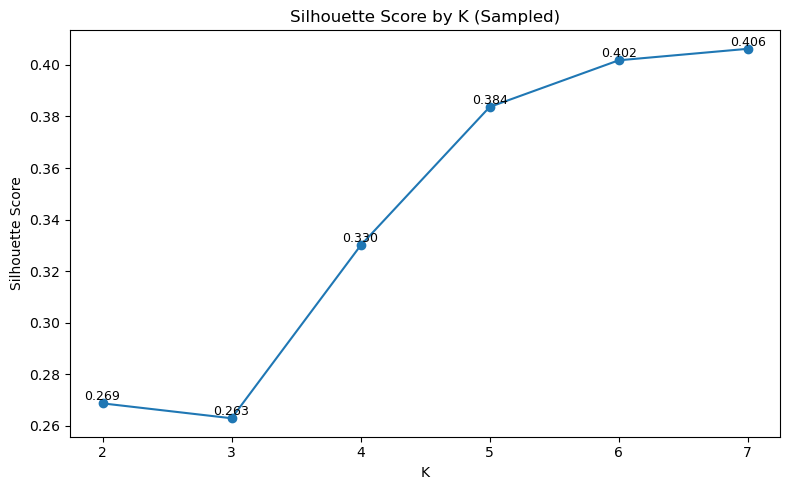

In [101]:
k_range = range(2, 8)
rng = np.random.default_rng(42)

sample_size = 2000
if X_scaled.shape[0] > sample_size:
    idx = rng.choice(X_scaled.shape[0], size=sample_size, replace=False)
    X_sample = X_scaled[idx]
else:
    X_sample = X_scaled

sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, labels))

plt.figure(figsize=(8,5))
plt.plot(list(k_range), sil_scores, marker="o")
plt.title("Silhouette Score by K (Sampled)")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

for k, v in zip(list(k_range), sil_scores):
    plt.text(k, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 6) Fit Final KMeans + Assign Segment Labels

Pick a K that balances interpretability and silhouette.
Defaulting to K=4 is often reasonable for user-facing segmentation.

In [104]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
seg_df["cluster"] = kmeans.fit_predict(X_scaled)

seg_df["cluster"].value_counts().sort_index()

cluster
0     8413
1    24886
2     8377
3     8324
Name: count, dtype: int64

## 7) Persona Naming (LLM-Friendly)

Because the dataset is snapshot-based, personas should be phrased in a way that
does not imply long-term behavior.

We combine:
- Spend tier
- Most common categories in the cluster (as context)
- Age band (optional)

This produces labels that sound natural in a coaching product.

In [107]:
# Profile numeric features
profile = seg_df.groupby("cluster").agg(
    avg_amount=("transaction_amount", "mean"),
    avg_age=("age", "mean")
).round(2)

# Top categories per cluster
top_cat = (
    seg_df.groupby(["cluster", "category"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)

top_cat.head(10), profile

(   cluster     category  count
 0        0   Restaurant   8413
 3        1       Market   8382
 1        1     Clothing   8261
 2        1     Cosmetic   8243
 4        2       Travel   8377
 5        3  Electronics   8324,
          avg_amount  avg_age
 cluster                     
 0             55.21    48.43
 1            174.68    48.49
 2           1539.96    48.52
 3            527.88    48.58)

In [109]:
# Get top category per cluster
top_cat_one = top_cat.groupby("cluster").head(1).set_index("cluster")["category"].to_dict()

def persona_name(row):
    cat = top_cat_one.get(row["cluster"], "General")
    return f"{row['spend_tier']} Spend — {cat}"

seg_df["persona"] = seg_df.apply(persona_name, axis=1)

seg_df[["customer_id", "transaction_amount", "spend_tier", "category", "cluster", "persona"]].head(10)

,customer_id,transaction_amount,spend_tier,category,cluster,persona
0,29,27.02,Low,Restaurant,0,Low Spend — Restaurant
1,51,1898.56,Very High,Travel,2,Very High Spend — Travel
2,54,166.30,Low,Clothing,1,Low Spend — Market
3,83,125.85,Low,Clothing,1,Low Spend — Market
4,90,18.16,Low,Restaurant,0,Low Spend — Restaurant
5,105,76.82,Low,Restaurant,0,Low Spend — Restaurant
6,110,231.57,Mid,Clothing,1,Mid Spend — Market
7,123,169.44,Low,Market,1,Low Spend — Market
8,132,129.93,Low,Travel,2,Low Spend — Travel
9,154,12.85,Low,Market,1,Low Spend — Market


## 8) Save Persona Dataset

This file will be used by the Hugging Face app and LLM prompts.

In [112]:
seg_df.to_csv("customer_personas_snapshot.csv", index=False)
print("✅ Saved: customer_personas_snapshot.csv")

✅ Saved: customer_personas_snapshot.csv


## Summary

- The dataset contains one transaction per customer, so multi-transaction behavioral personas are not measurable.
- We created snapshot-based personas using spend tiers, category context, and optional clustering.
- The output dataset `customer_personas_snapshot.csv` is ready to power an LLM-based financial coaching experience.

Next:
Proceed to supervised modeling (high spender classification) and LLM integration for deployment.